Required imports for model.

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

Loading training dataset and splitting it into features 'X' (destination coordiantes, crime score, public safety score and crime severity) and target 'y' (safety scores).

In [2]:
# training_set = pd.read_csv("C:\\Users\\loisp\\Documents\\Year3\\Dissertation\\Proutect\\Proutect\\csv-json-files\\training_set.csv")

# X = training_set.drop('Safety Score', axis=1)
# y = training_set['Safety Score']
# print(X)
# print(y)

Code to work out a particular lon/lat radius for some coordinates. 

In [3]:
def get_lat_lon_ranges(lat, lon, radius):
    # Earth's radius in meters
    EARTH_RADIUS = 6378137

    # Convert latitude and longitude from degrees to radians
    lat_rad = np.radians(lat)

    # Calculate deltas
    dLat = radius/EARTH_RADIUS
    dLon = radius/(EARTH_RADIUS * np.cos(lat_rad))

    # Convert deltas from radians to degrees
    dLat_deg = np.degrees(dLat)
    dLon_deg = np.degrees(dLon)

    # Define ranges
    lat_range = (lat - dLat_deg, lat + dLat_deg)
    lon_range = (lon - dLon_deg, lon + dLon_deg)

    return lat_range, lon_range

Defines crime datasets. 

In [4]:
crime_data_2021 = pd.read_csv('C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\crimes_in_range_2021.csv')
crime_data_2022 = pd.read_csv('C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\crimes_in_range_2022.csv')
crime_data_2023 = pd.read_csv('C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\crimes_in_range_2023.csv')

all_crime = pd.concat([crime_data_2021, crime_data_2022, crime_data_2023], ignore_index=True)

# Defining the crime severity score of each crime. 
crime_severity_scores = {
    "Drugs" : 2,
    "Shoplifting" : 2,
    "Burglary" : 5,
    "Theft from the person" : 8,
    "Possession of weapons" : 9,
    "Violence and sexual offences" : 10,
    "Criminal damage and arson" : 7,
    "Vehicle crime" : 4,
    "Bicycle theft " : 2,
    "Other theft" : 1,
    "Public order" : 1,
    "Robbery" : 5, 
    "Anti-social behaviour" : 5,
    "Other crime" : 1
}

# Function to get a spreadsheet of total crimes in a specified range.
def get_crimes_in_range(all_crime_data, long_min, long_max, lat_min, lat_max, crime_severity_scores):
    # Filter the data to only include crimes within the specified ranges
    crimes_in_range = all_crime_data[
        (all_crime_data['Longitude'] >= long_min) & 
        (all_crime_data['Longitude'] <= long_max) & 
        (all_crime_data['Latitude'] >= lat_min) & 
        (all_crime_data['Latitude'] <= lat_max)
    ]

    crimes_in_range = crimes_in_range.copy()
    
    # Add severity score for each crime
    crimes_in_range['Severity Score'] = crimes_in_range['Crime type'].map(crime_severity_scores)

    if not crimes_in_range.empty:
        avg_ss = crimes_in_range['Severity Score'].mean()
    else:
        avg_ss = 0

    return len(crimes_in_range), avg_ss

In [5]:
# Initialize dictionary to hold crime and safety score data
crime_dictionary = {}

# Iterate through the crimes
for index, row in all_crime.iterrows():
    # Convert to float once and use variables
    lat = float(row["Latitude"])
    lon = float(row["Longitude"])
    
    # Get coordinate ranges for 250m radius
    lat_range, lon_range = get_lat_lon_ranges(lat, lon, 250)
    
    # Define the coordinate pair
    coords = (lat, lon)
    
    # Initialize or update dictionary for the coords
    if coords not in crime_dictionary:
        crime_dictionary[coords] = [0, 0]  # Initialize if not present
    
    # Get number of crimes and average severity score in the range
    num_crimes, avg_ss = get_crimes_in_range(all_crime, lon_range[0], lat_range[0], lon_range[1], lat_range[1], crime_severity_scores)
    
    # Update dictionary values
    total_crimes = len(all_crime)

    crime_dictionary[coords][0] += (total_crimes - num_crimes) / total_crimes
    crime_dictionary[coords][1] += (10 - avg_ss) / 10

# Print the dictionary
print(crime_dictionary)

{(52.279611, -1.501874): [10.946635864857058, 3.9759036144578315], (52.272738, -1.498624): [1.9978053710655501, 0.8105263157894737], (52.276068, -1.499642): [4.982385215131389, 1.7459016393442623], (52.294499, -1.530402): [5.951371643084032, 4.142934016655989], (52.293096, -1.530358): [22.52572913658679, 15.489661924030795], (52.294583, -1.529037): [19.291077100779674, 11.642115085536545], (52.292775, -1.530962): [20.315333525844622, 15.406522518217667], (52.292862, -1.534759): [10.678140340745014, 13.607589937322924], (52.292301, -1.529428): [9.15160265665608, 5.644094606809281], (52.291967, -1.535736): [46.56367311579565, 59.93845101726797], (52.288299, -1.535877): [51.198151891423564, 39.2101922631457], (52.293131, -1.536853): [34.319376263355515, 47.870264917058584], (52.29137, -1.532561): [5.977822697083455, 5.103976468024839], (52.289332, -1.537743): [4.50736355760901, 4.380061746837964], (52.292609, -1.536712): [71.7016459717007, 99.29088802449695], (52.289063, -1.535854): [14.4

Setting up data frame for classification analysis - setting the classification feature as a continous, average safety rating from users, while additionally adding the crime rate of each coordinate.  

In [6]:
from sklearn.preprocessing import StandardScaler

all_feedback = pd.read_csv('C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\joinedfeedback.csv')
ratings = all_feedback.loc[:, ['Latitude', 'Longitude', 'q1', 'q2', 'q3', 'q4']]
responses =  all_feedback.loc[:, ['Latitude', 'Longitude', 'responseList']]

# Initialize dictionary to hold crime and safety score data
crime_dictionary = {}

# Iterate through the crimes
for index, row in ratings.iterrows():
    # Convert to float once and use variables
    lat = float(row["Latitude"])
    lon = float(row["Longitude"])
    
    # Get coordinate ranges for 250m radius
    lat_range, lon_range = get_lat_lon_ranges(lat, lon, 250)
    
    # Define the coordinate pair
    coords = (lat, lon)
    
    # Initialize or update dictionary for the coords
    if coords not in crime_dictionary:
        crime_dictionary[coords] = [0, 0]  # Initialize if not present
    
    # Get number of crimes and average severity score in the range
    num_crimes, avg_ss = get_crimes_in_range(all_crime, lon_range[0], lat_range[0], lon_range[1], lat_range[1], crime_severity_scores)
    
    # Update dictionary values
    total_crimes = len(all_crime)

    crime_dictionary[coords][0] += (total_crimes - num_crimes) / total_crimes
    crime_dictionary[coords][1] += avg_ss

# Appending the average "safety score" that is given by the users 
classification_list = []
crime_num_list = []
crime_sev_list = []

for index, row in ratings.iterrows():
    classification_list.append(row['q1'])

    coords = (row["Latitude"], row["Longitude"])

    crime_num_list.append(crime_dictionary[coords][0])
    crime_sev_list.append(crime_dictionary[coords][1])


ratings["Classification"] = classification_list
ratings["Crime Score"] = crime_num_list
ratings["Severity Score"] = crime_sev_list

scaler = StandardScaler()
ratings[['Crime Score', 'Severity Score']] = scaler.fit_transform(ratings[['Crime Score', 'Severity Score']])

# ratings
# ratings["Classification"].value_counts()



X_2 = ratings.drop(['Classification', 'q1'], axis=1)

y_2 = ratings['Classification']

print(X_2)
print(y_2)

      Latitude  Longitude    q2    q3    q4  Crime Score  Severity Score
0    52.285500  -1.558030  4.00  4.00  1.00    -0.284874       -0.590821
1    52.286880  -1.533620  3.00  2.00  1.00     0.322640        0.675528
2    52.279250  -1.544650  3.00  2.00  1.00     1.243395        0.354504
3    52.290777  -1.533494  3.75  4.00  1.75    -0.368788       -0.484453
4    52.275950  -1.516430  3.00  3.00  1.00     2.334851        1.073728
..         ...        ...   ...   ...   ...          ...             ...
779  52.292370  -1.548190  2.75  3.25  2.00    -1.690146       -1.510475
780  52.285970  -1.536280  2.00  1.50  1.00     0.418911        0.921843
781  52.282960  -1.545510  2.00  1.50  1.00     0.349079       -0.771445
782  52.288400  -1.538270  2.00  1.00  1.00    -0.113310        0.445161
783  52.289680  -1.542560  2.00  3.00  2.00    -0.776288       -0.879856

[784 rows x 7 columns]
0      3.0
1      3.0
2      3.0
3      3.5
4      3.0
      ... 
779    3.0
780    2.5
781    2.5
7

In [7]:
# crime_data_2021 = pd.read_csv('C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\crimes_in_range_2021.csv')
# crime_data_2022 = pd.read_csv('C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\crimes_in_range_2022.csv')
# crime_data_2023 = pd.read_csv('C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\crimes_in_range_2023.csv')

# all_crime = pd.concat([crime_data_2021, crime_data_2022, crime_data_2023], ignore_index=True)

# # Defining the crime severity score of each crime. 
# crime_severity_scores = {
#     "Drugs" : 2,
#     "Shoplifting" : 2,
#     "Burglary" : 5,
#     "Theft from the person" : 8,
#     "Possession of weapons" : 9,
#     "Violence and sexual offences" : 10,
#     "Criminal damage and arson" : 7,
#     "Vehicle crime" : 4,
#     "Bicycle theft " : 2,
#     "Other theft" : 1,
#     "Public order" : 1,
#     "Robbery" : 5, 
#     "Anti-social behaviour" : 5,
#     "Other crime" : 1
# }


# # Function to get a spreadsheet of total crimes in a specified range.
# def get_crimes_in_range(all_crime_data, long_min, long_max, lat_min, lat_max, crime_severity_scores):
#     # Filter the data to only include crimes within the specified ranges
#     crimes_in_range = all_crime_data[
#         (all_crime_data['Longitude'] >= long_min) & 
#         (all_crime_data['Longitude'] <= long_max) & 
#         (all_crime_data['Latitude'] >= lat_min) & 
#         (all_crime_data['Latitude'] <= lat_max)
#     ]

#     crimes_in_range = crimes_in_range.copy()
    
#     # Add severity score for each crime
#     crimes_in_range['Severity Score'] = crimes_in_range['Crime type'].map(crime_severity_scores)
#     # print(crimes_in_range)
#     # Calculate average severity score for the crimes in the range
    
#     if not crimes_in_range.empty:
#         average_severity_score = crimes_in_range['Severity Score'].mean()
#     else:
#         average_severity_score = 0

#     return len(crimes_in_range), average_severity_score


In [8]:
import pandas as pd

In [9]:
safety_scores = pd.read_csv("C:\\Users\\User\\Documents\\GitHub\\proutectapp\\csv-json-files\\training_set_new.csv")

X = safety_scores.drop(['Safety Score'], axis=1)

y = safety_scores['Safety Score']


In [10]:
safety_scores

,Latitude,Longitude,Year,Crime Score,Crime Severity Score,Public Space Score,Safety Score
0,52.295042,-1.570058,2021,0.982030,0.366667,0.000000,13.806207
1,52.295042,-1.562762,2021,0.988191,0.336232,0.000000,11.580906
2,52.295042,-1.555381,2021,0.989560,0.354098,0.003115,28.078859
3,52.295042,-1.548171,2021,0.979805,0.480172,0.006231,37.731480
4,52.295042,-1.540875,2021,0.916824,0.441026,0.015576,32.581060
...,...,...,...,...,...,...,...
226,52.268551,-1.526155,2023,0.989420,0.347458,0.012461,27.689434
227,52.268551,-1.518688,2023,0.994357,0.284375,0.003115,22.668357
228,52.268551,-1.511564,2023,0.999471,0.000000,0.000000,-15.000000
229,52.268551,-1.504140,2023,1.000000,1.000000,0.000000,65.000000


In [11]:
all_feedback

,Latitude,Longitude,q1,q2,q3,q4,feedback date list,responseList,dateList
0,52.285500,-1.558030,3.0,4.00,4.00,1.00,2024-02-22T22:42:06.016Z; 2024-02-22T22:42:06....,"The route was busy with the public, but there ...",2024-02-22T22:42:06.016Z; 2024-02-22T22:42:06....
1,52.286880,-1.533620,3.0,3.00,2.00,1.00,2024-02-17T12:43:29.355Z; 2024-02-17T12:43:29....,"There was a long, isolated road with a lack of...",2024-02-17T12:43:29.355Z; 2024-02-17T12:43:29....
2,52.279250,-1.544650,3.0,3.00,2.00,1.00,2024-02-17T12:43:29.355Z; 2024-02-17T12:43:29....,"There was a long, isolated road with a lack of...",2024-02-17T12:43:29.355Z; 2024-02-17T12:43:29....
3,52.290777,-1.533494,3.5,3.75,4.00,1.75,2024-02-17T12:46:14.436Z; 2024-02-22T22:12:14....,The route was busy with the public as there we...,2024-02-17T12:46:14.436Z; 2024-02-22T22:12:14....
4,52.275950,-1.516430,3.0,3.00,3.00,1.00,2024-02-23T14:21:02.709Z; 2024-02-23T14:21:02....,"Well-lit street, was quite busy with other mem...",2024-02-23T14:21:02.709Z; 2024-02-23T14:21:02....
...,...,...,...,...,...,...,...,...,...
779,52.292370,-1.548190,3.0,2.75,3.25,2.00,2024-02-25T23:49:40.546Z; 2024-02-25T23:49:40....,A really nice walk to do in the evening.; The ...,2024-02-25T23:49:40.546Z; 2024-02-25T23:51:03....
780,52.285970,-1.536280,2.5,2.00,1.50,1.00,2024-02-25T23:25:35.435Z; 2024-02-25T23:27:56....,The route felt fairly safe with some street li...,2024-02-25T23:25:35.435Z; 2024-02-25T23:27:56....
781,52.282960,-1.545510,2.5,2.00,1.50,1.00,2024-02-25T23:25:35.435Z; 2024-02-25T23:27:56....,The route felt fairly safe with some street li...,2024-02-25T23:25:35.435Z; 2024-02-25T23:27:56....
782,52.288400,-1.538270,2.0,2.00,1.00,1.00,2024-02-25T23:34:29.133Z,Walking through the park made me feel uneasy a...,2024-02-25T23:34:29.133Z


Split data into training/test set.

In [12]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 80% : 20% split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [64]:
regressor = RandomForestRegressor(n_estimators=100, random_state=42, oob_score = True)
regressor.fit(X_train, y_train)

RandomForestRegressor(n_estimators=500, oob_score=True, random_state=42)

In [65]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculates and displays the Out-of-bag (OOB) score
oob_score = regressor.oob_score_
print(f'Out-of-Bag Score: {oob_score}')

# Predicting on the test set
y_pred = regressor.predict(X_test)

# Calculating the Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse}")

mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae}")

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse}")

r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2}')

Out-of-Bag Score: 0.9751906579390266
RMSE: 1.636519796466721
Mean Absolute Error (MAE): 0.8739871776036021
Mean Squared Error (MSE): 2.6781970442274785
R-squared: 0.9910626511763244


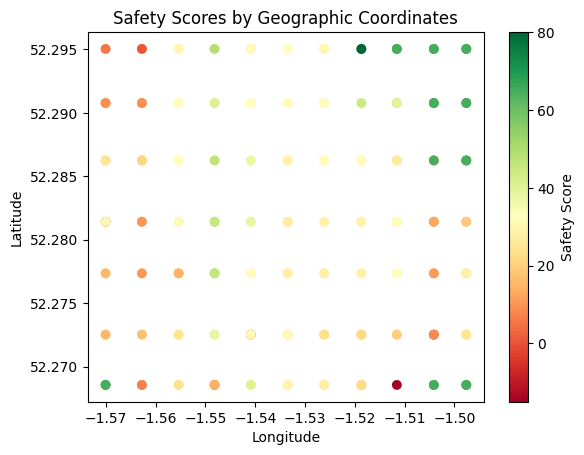

In [66]:
# import numpy as np
# X_grid = np.arange(min(X),max(X),0.01)
# X_grid = X_grid.reshape(len(X_grid),1) 

# plt.scatter(X,y, color='blue') #plotting real points
# plt.plot(X_grid, regressor.predict(X_grid),color='green') #plotting for predict points

# plt.title("Random Forest Regression Results")
# plt.xlabel('Coordinates')
# plt.ylabel('Safety Score')
# plt.show()

import numpy as np
import matplotlib.pyplot as plt

# Assuming X is a 2D array with shape (n_samples, 2) where the first column is longitude and the second is latitude
# and 'y' is the safety score

longitude = X['Longitude']
latitude = X['Latitude']
safety_scores = y    # Safety scores

plt.scatter(longitude, latitude, c=safety_scores, cmap='RdYlGn')
plt.colorbar(label='Safety Score')  # Adds a color bar to interpret the safety score
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title("Safety Scores by Geographic Coordinates")

plt.show()


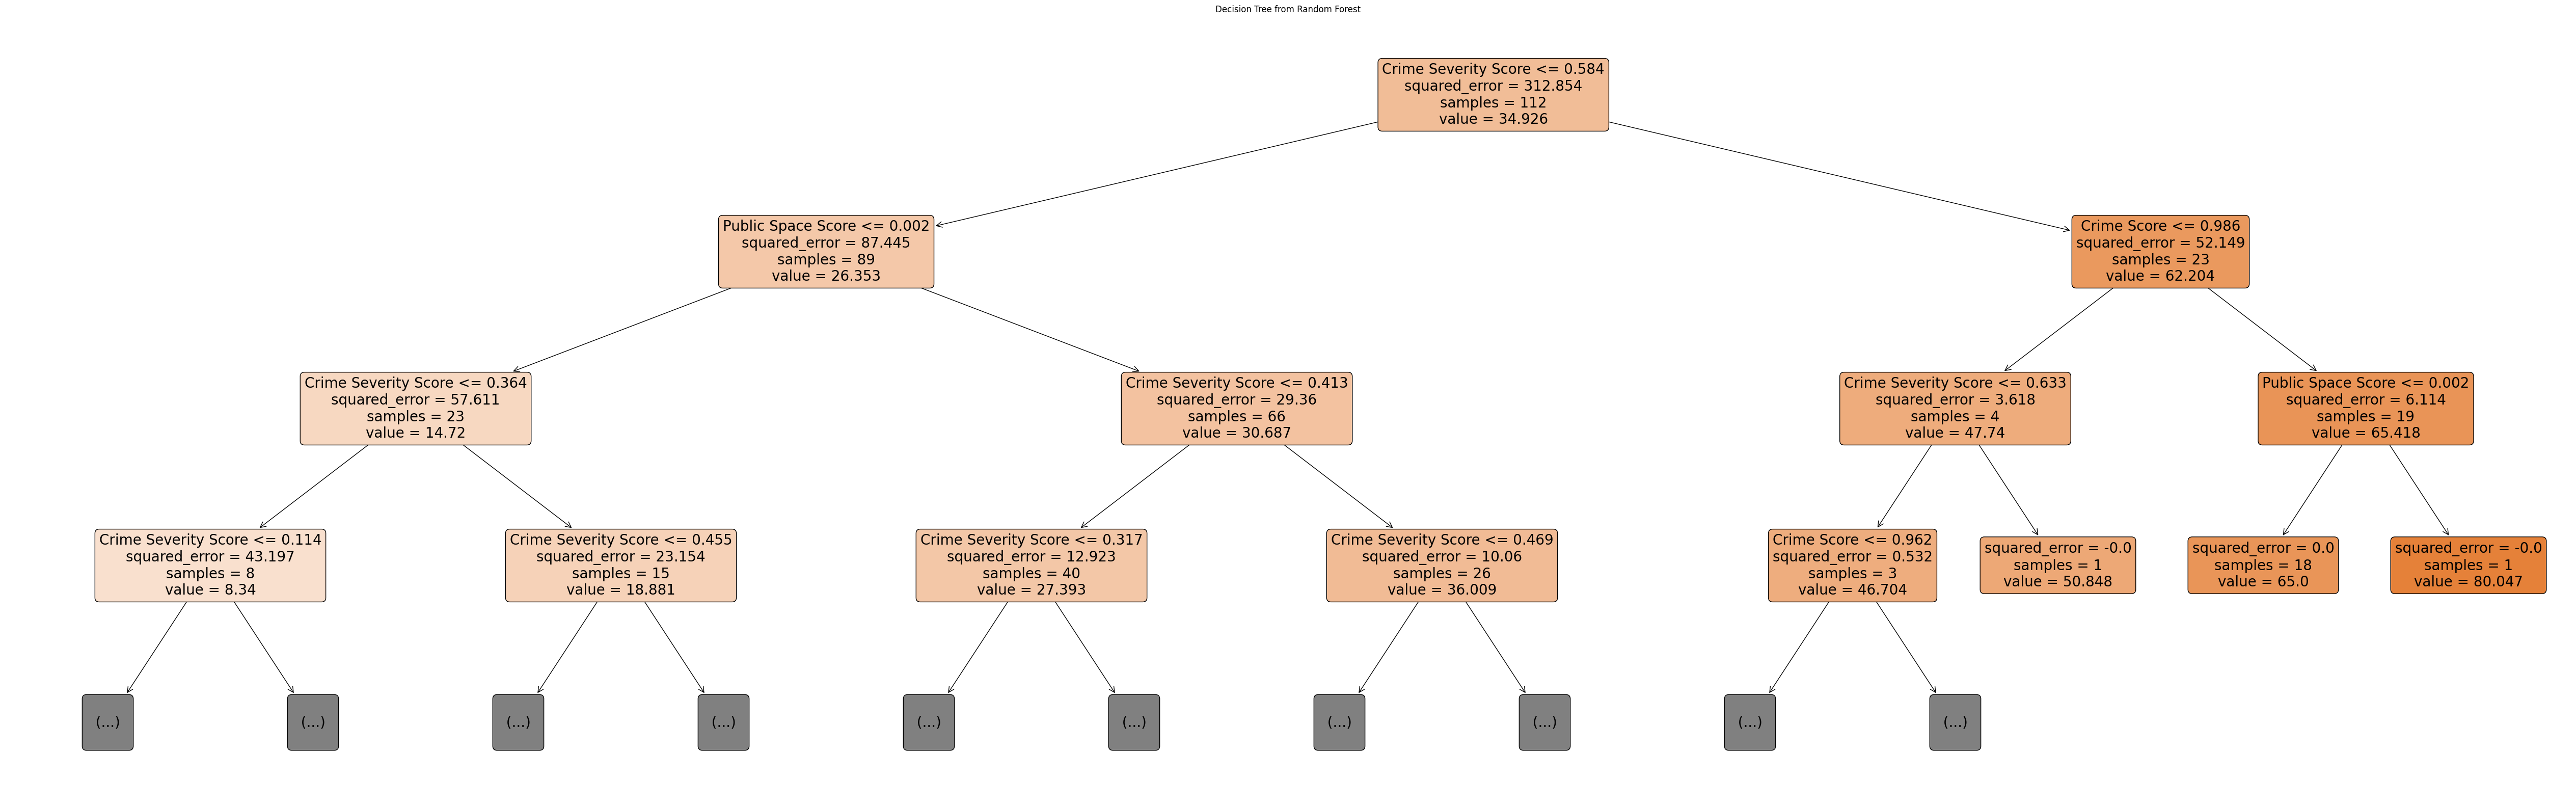

In [67]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Assuming regressor is your trained Random Forest model
# Pick one tree from the forest, e.g., the first tree (index 0)
tree_to_plot = regressor.estimators_[5]

# Plot the decision tree
plt.figure(figsize=(65, 20))
plot_tree(tree_to_plot, feature_names=X.columns.tolist(), filled=True, rounded=True, max_depth=3, fontsize=20)
plt.title("Decision Tree from Random Forest")
plt.show()

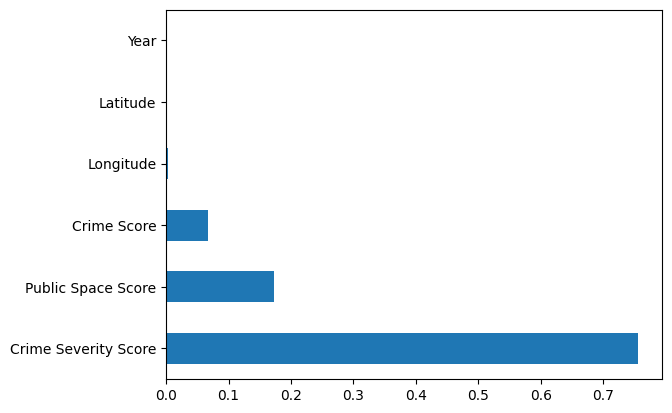

In [68]:
feature_importances = pd.Series(regressor.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')  # Top 10 features
plt.show()

Text(0.5, 1.0, 'Pie Chart of Feature Importances')

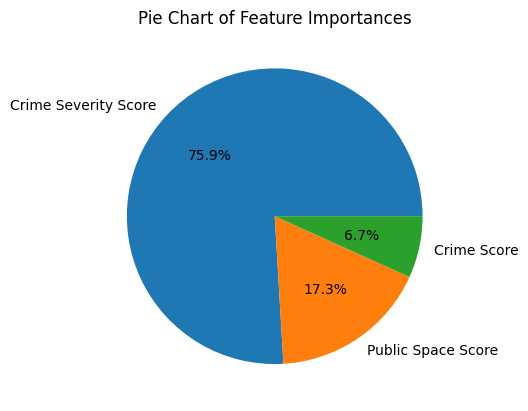

In [69]:
feature_importances.nlargest(3).plot(kind='pie', autopct='%1.1f%%')
plt.title('Pie Chart of Feature Importances')


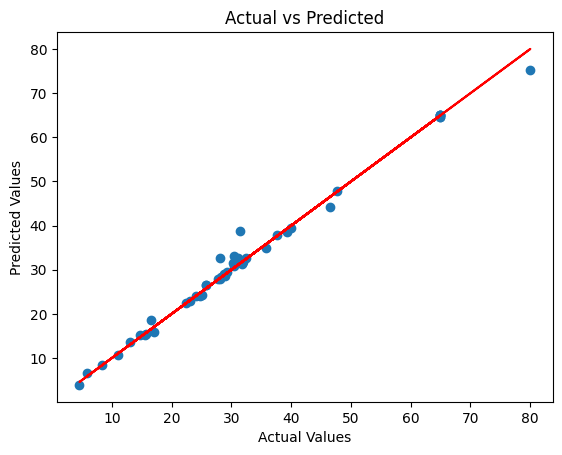

In [70]:
import matplotlib.pyplot as plt

# Scatter plot for actual vs predicted values
plt.scatter(x=y_test, y=y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.plot(y_test, y_test, color='red')  # Line for perfect predictions
plt.show()